# Skin Disease Classification 

The goal of this notebook is to train a model to perform multi-class image classification: given a skin image, predict one of 9 disease labels. The success will be measured using 1) Overall accuracy, and 2) class-wise precision/recall/F1. I will be using 2 separate pipelines. Method A will be to flatten images, then do PCA to reduce dimensionality and finally classify using an SVM. Method B will be transfer learning with a pretrained CNN (ResNet18) that is fine-tuned on this specific dataset. The actual structure of the dataset is as follows:
1. Dataset Exploration
2. Preprocessing
3. PCA + SVM without K-fold validation
4. PCA + SVM with K-fold validation
5. CNN
6. Comparison of both methods
7. Ethical Considerations
8. Closing Remarks

In [ ]:
# Imports
# Core Python + paths
import os
from pathlib import Path
from collections import Counter

# Numerics and plotting
import numpy as np
import matplotlib.pyplot as plt

# Image handling
from PIL import Image

# PyTorch + torchvision for CNNs
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Metrics (later, for evaluation)
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


# Make plots show nicely in Jupyter
%matplotlib inline


## Dataset Exploration

Because this is an image dataset, there are some different steps that need to be taken. First, I went through and briefly scanned each image. I noticed that for the disease labeled "atopic dermatitis" the images were often more zoomed out (included a full hand/leg) which introduced background bias that was not present in most of the other classes. Because I am not a dermatologist, cropping what I believe to be the "diseased" portion would be unwise, which is why I will simply have to facilitate the model in learning what the background is.

While this is a processed dataset, there were still a few images which were definitely invalid. They were either completely black or unreadable, and the files contained no usable pixel information and therefore would not be able to contribute meaningfullly to the learning process. I removed 3 images from the "Tinea Ringworm Candidiasis" training data which is shown below. 

My general thought process that I followed through the notebook is as follows:
1. I need to have a dataset that is usable, hence why pre processing exists. In order to ensure that is the case, I looked through all the images briefly (it didn't take that long to scan) and removed any images that I was 100% sure were outliers (would provide no data and would not accurately reflect how well the model can recognize a skin disease)
2. Now that I have a dataset that I can use, I need to figure out how to extract features. As a human being, in order to recognize these different diseases I would look at color first, and then the pattern (ring disease is very recognizeable as a non-doctor). Now the next problem is 
3. Scale. Scale is very difficult, because some of these images are very zoomed in, and others zoomed out. It makes the resizing process difficult, but my way of consolidating that was by recognizing those inconsistencies in preprocessing and seeing whether those diseases are the ones being reflected poorly in the results.
4. How to actually do the machine learning. I've never done this before, so I'm going to have to learn. Time and time again, throughout class, it was emphasized that you can't just use chatGPT to write everything for you, because I'll get an answer but won't be able to actually know what was going on behind the scenes. Since it's a learning process, my strategy was to explain my own thought process to a generative AI to aid me in writing code (such as how to make a confusion matrix to visualize, not the AI giving me that idea) and so on. I watched YouTube videos as well, but ultimately my workflow consisted of me checking my notes for theory, then writing out my thought process and finally using AI to help write the actual code.

### Datasets and DataLoaders 

In [ ]:
# remove some images

bad_images = [
    "Split_smol/train/Tinea Ringworm Candidiasis/aug_0_F2.large.jpg",
    "Split_smol/train/Tinea Ringworm Candidiasis/aug_0_Screenshot 2021-09-14 112600.png"
    "Split_smol/train/Tinea Ringworm Candidiasis/aug_0_300px-Ringworm_on_the_arm,_or_tinea_corporis_due_to_Trichophyton_mentagrophytes_PHIL_2938_lores.jpg"
]

for path in bad_images:
    print("Showing:", path)
    try:
        img = Image.open(path)
        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.title(f"Removed: {path}")
        plt.axis("off")
    except Exception as e:
        print(f"Could not display {path}: {e}")

As mentioned above, I searched through the dataset myself and found a few images that I was sure were unnecessary and provided no actual value to the dataset. They were essentially too zoomed in for any meaningful infomration to be usable, which is why I deleted them.

In [ ]:
# pointing the notebook to the dataset
data_root = Path("Split_smol")  
train_dir = data_root / "train"
val_dir   = data_root / "val"

print(train_dir)
print(val_dir)

In [ ]:
train_dataset = datasets.ImageFolder(root=train_dir)
val_dataset   = datasets.ImageFolder(root=val_dir)

print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))



The dataset contains 695 training images and 181 validation images across 9-skin condition classes. This is definitely alrge enough to train a small model, but it is also still small enough that I run the risk of overfitting--especially for deep networks. When I looked through the images I noticed that the classes can be visually similar, like melanoma vs nevus, so I will have to track the perclass metrics rather than solely relying on accuracy, which was the plan to begin with.

In [ ]:
clean_samples = []
bad_samples = []

for path, label in train_dataset.samples:
    try:
        with Image.open(path) as img:
            img.verify()   # verify image integrity
        clean_samples.append((path, label))
    except Exception as e:
        print("Bad image:", path)
        bad_samples.append((path, e))

print("Good images:", len(clean_samples))
print("Bad images:", len(bad_samples))

# Replace dataset samples with only valid files
train_dataset.samples = clean_samples
train_dataset.imgs = clean_samples


I used this simple code to detect if the images could actually be processed properly, and it turns out that all of the training data is now good. A single corrupt image can (and did) crash a training mid-run, which would waste time and produce weird and bordernline indiscernable errors. This is a lightweight check on whether or not the image is valid, and I can separate bad samples if necessary.

In [ ]:
from collections import Counter

train_counts = Counter([label for _, label in train_dataset.samples])
val_counts   = Counter([label for _, label in val_dataset.samples])

print("Training counts per class:")
for cls_idx, count in train_counts.items():
    print(f"{train_dataset.classes[cls_idx]}: {count}")

print("\nValidation counts per class:")
for cls_idx, count in val_counts.items():
    print(f"{val_dataset.classes[cls_idx]}: {count}")

This gives us a clear idea of how many images there are per class for both the training data and validation data. The most significant thing to note here is that the Tinea Ringworm Candidiasis has the least amount of images which could affect the accuracy of the model for that class. 

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def show_samples(dataset, n=3):
    classes = dataset.classes
    idxs_by_class = {i: [] for i in range(len(classes))}

    # Group all image paths by class ID
    for idx, (_, label) in enumerate(dataset.samples):
        idxs_by_class[label].append(idx)

    fig, ax = plt.subplots(len(classes), n, figsize=(n*3, len(classes)*3))

    for class_idx in range(len(classes)):
        sample_indices = random.sample(idxs_by_class[class_idx], n)
        for j, sample_idx in enumerate(sample_indices):
            path, _ = dataset.samples[sample_idx]
            img = Image.open(path)

            axis = ax[class_idx, j]
            axis.imshow(img)
            axis.axis("off")
            if j == 0:
                axis.set_title(classes[class_idx])

    plt.tight_layout()
    plt.show()

show_samples(train_dataset)


I wanted to see if the images were being loaded correctly so I just displayed 3 images per class, and it worked great. From this it is clear that there are lots of similarities amongst the classes. It is also clear to see that one of the classes (atopic dermatitis) has very different images--as in there are zoomed out. This is something I will have to consider.

In [ ]:
sizes = [Image.open(p).size for p, _ in train_dataset.samples]
widths, heights = zip(*sizes)

print("Min width:", min(widths))
print("Max width:", max(widths))
print("Mean width:", sum(widths)/len(widths))
print("Mean height:", sum(heights)/len(heights))


After looking at a sample of the images in this format, and then also checking the size of the images, if becomes very clear that resizing of the images must be done. This will be the first step in the faeture learning process.

## Feature Extraction/Feature Learning

In [ ]:
IMG_SIZE = 224

svm_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

I resize the images to 224 and also apply ImageNet normalization. I chose the mean and std values as they are because they are the standard ImageNet normalization constants. This is important because ResNet18 (which will be used later for the CNN) pretrained weights were learned on ImageNet with this normalization. Matching it keeps feature distrbutions consistent and it improves transfer learning effectiveness. 

In [ ]:
from torchvision import datasets

train_dataset_svm = datasets.ImageFolder(root=train_dir, transform=svm_transform)
val_dataset_svm   = datasets.ImageFolder(root=val_dir, transform=svm_transform)

print("Train samples:", len(train_dataset_svm))
print("Val samples:", len(val_dataset_svm))
print("Classes:", train_dataset_svm.classes)

Using the datasets method from torchvision I can easily organize the data into actual usable datasets. To ensure that this process went smoothly, I include a couple of sanity checks. These just printed out how many training and validation samples there were, as well as all the classes. Thankfully, those passed.

In [ ]:
def clean_imagefolder(ds, name="dataset"):
    cleaned = []
    dropped = []
    for path, label in ds.samples:
        p = Path(path)
        # 1) Skip if file isn't on disk
        if not p.exists():
            print(f"[{name}] Missing on disk, dropping:", p)
            dropped.append((path, label, "missing on disk"))
            continue
        # 2) Skip if PIL can't open it
        try:
            with Image.open(p) as img:
                img.verify()
            cleaned.append((path, label))
        except Exception as e:
            print(f"[{name}] Unopenable, dropping:", p, "->", e)
            dropped.append((path, label, str(e)))
    ds.samples = cleaned
    ds.imgs = cleaned  # torchvision uses both
    print(f"[{name}] Kept {len(cleaned)} images, dropped {len(dropped)}")
    return dropped

_ = clean_imagefolder(train_dataset_svm, name="train_svm")
_ = clean_imagefolder(val_dataset_svm,   name="val_svm")

missing = [p for p, _ in val_dataset_svm.samples if not Path(p).exists()]
print("Missing in val_dataset_svm:", missing)


I was consistently running into an error when trying to train my models because some images didn't exist, even though they clearly did. I then added this code block to further "clean" my dataset and ensure before trying to train my models that all the files were readable, and if they weren' then they would be dropped. That is exactly what happened here. I later realized that the reason this specific file was dropped was because the name of it was too long and it wasn't being stored properly as a result, which is quite strange and definitely not something I would have noticed had I not run this test.

In [ ]:
def dataset_to_matrix(dataset):
    X = []
    y = []

    for img_tensor, label in dataset:
        # img_tensor: (3, IMG_SIZE, IMG_SIZE)
        flat = img_tensor.view(-1).cpu().numpy()
        X.append(flat)
        y.append(label)

    X = np.stack(X)      # (n_samples, n_features)
    y = np.array(y)      # (n_samples,)

    return X, y

X_train, y_train = dataset_to_matrix(train_dataset_svm)
X_val, y_val     = dataset_to_matrix(val_dataset_svm)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

Because PCA/SVM expects a 2D feature matrix X with the shape (n_samples, n_features), I converted each image from a tensor of shape (3,224,224) into a single long feature vector. This feature vector has 150,528 features! This intentionally discards spatial structure that CNNs use, but it provides a clean baseline to compare against deep learning.

## Processing using PCA + SVM

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_probe = PCA().fit(X_train)

cumvar = np.cumsum(pca_probe.explained_variance_ratio_)

plt.figure(figsize=(7,5))
plt.plot(cumvar)
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.grid(True)
plt.show()

n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1

print("Components for 90% variance:", n_90)
print("Components for 95% variance:", n_95)


At a high level, PCA finds new orthogonal axes known as principal components that capture the most variance in the data. Since my flattened images have ~150k raw pixel features, PCA will reduce dimensionality to something more usable, and can also remove noise/redundancy. In order to decide just how many components I would need, I decided to plot this graph which would allow me to easily visualize the trade off between more features and variance. I also printed a couple of statements that show the point at which 90% and 95% variance are captured by the features. I figured that a good balance point would be 95% since after that the increase per component drastically decreases which would make computations unnecessarily long. That is why I initially chose 89 as the number of PCA components.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV

pca_components = 89 # since this was 95% accuracy

I should also mention that this was before I had watched the lecture on K-fold validation. I didn't realize there was a formal process to finding the best parameters, or rather I didn't realize I was missing out on it. That is the reason why I decided to both this method of finding the number of pca_components and also using K-fold validation. 

In [ ]:
# code that will be used to create confusion matrices for the rest of the notebook

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_cm(
    y_true,
    y_pred,
    title,
    class_names,
    normalize=None,
    figsize=(8, 7),
    font_size=10,
    label_font_size=11,
    title_font_size=14
):
    cm = confusion_matrix(y_true, y_pred, normalize=normalize)

    fig, ax = plt.subplots(figsize=figsize)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format=".2f" if normalize else "d",
        colorbar=True
    )

    ax.set_title(title, fontsize=title_font_size, pad=12)
    ax.set_xlabel("Predicted label", fontsize=label_font_size)
    ax.set_ylabel("True label", fontsize=label_font_size)

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=font_size)
    plt.setp(ax.get_yticklabels(), fontsize=font_size)

    plt.tight_layout()
    plt.show()



#### SVM

In [ ]:
svm_baseline = Pipeline([
    ("pca", PCA(n_components=pca_components, whiten=True, random_state=42)),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

svm_baseline.fit(X_train, y_train)
y_pred_base = svm_baseline.predict(X_val)

# I chose those parameters sort of randomly on purpose

In [ ]:
pca_base = svm_baseline.named_steps["pca"]
print("Baseline variance explained:",
      pca_base.explained_variance_ratio_.sum())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

class_names = train_dataset_svm.classes

plot_cm(
    y_val,
    y_pred_base,
    "Baseline",
    class_names,
    normalize=None
)

plot_cm(
    y_val,
    y_pred_base,
    "Normalized Baseline",
    class_names,
    normalize="true"
)

print(classification_report(y_val, y_pred_base, target_names=class_names))




This baseline uses PCA + an RBF-kernel SVM with manually chosen hyperparameters to establish a baseline. The validation accuracy was ~61%, and the confusion matrix shows that several disease classes are frequently confused. In particular, Actinic Keratosis was confused for Dermatofibroma 60% of the time. While this is expected because flattening pixels removes spatial strucutre, it is still very interesting to see this error.  I would have expected melanoma and nevus to be confused for one another more often, but those errors seem to be spread out. However, the purpose of this baseline model was not to be extremely accurate but rather to demonstrate the value of K-fold cross validation and also the benefit of feature learning with CNNs, which will be shown later on.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV


svm_for_search = Pipeline([
    ("pca", PCA(whiten=True, random_state=42)),
    ("svm", SVC(kernel="rbf"))
])

param_grid = {
    "pca__n_components": [35, 60, 90, 140],
    "svm__C": [0.1, 1, 10, 15],
    "svm__gamma": ["scale", 0.01, 0.001],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    svm_for_search,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

# print("Best CV accuracy:", grid.best_score_)
# print("Best params:", grid.best_params_)

svm_cv_best = grid.best_estimator_
y_pred_cv = svm_cv_best.predict(X_val)


In [ ]:
print("Best parameters:", grid.best_params_)

The above code is used for cross-validation. GridSearchCV tries combinations of hyperparameters and selects the best based on cross-validated performance. The actual arrays themselves were handcrafted by me. I chose the pca_components intentionally based on the graph that was shown above. I wanted to include a value that was just above the 90% threshold, a value in between, a value at the 95% threshold, and then a value well above the rest. As for the C and gamma values, I researched online what would be good parameters to test and then inserted those in. As for the code itself, I did my best to understand what was going on. StratifiedKFold splits the data into K folds while preserving the class proportions in each fold which is obviously important. This is the essence of KCV. 

In [ ]:
pca_cv = svm_cv_best.named_steps["pca"]
print("CV PCA variance explained:",
      pca_cv.explained_variance_ratio_.sum())

In [ ]:
y_pred_cv = svm_cv_best.predict(X_val)

plot_cm(
    y_val,
    y_pred_cv,
    "K-Fold SVM",
    class_names,
    normalize=None
)

plot_cm(
    y_val,
    y_pred_cv,
    "K-Fold SVM Normalized",
    class_names,
    normalize="true"
)

print(classification_report(y_val, y_pred_cv, target_names=class_names))

In this dataset, cross-validation did not significantly improve over the baseline, suggesting that the issue isn't necessarily with the parameters, but rather the issue is the representation itself, which is flattened pixels. This motivates me to try out the second method, which is CNN transfer learning. It will learn the spatial features directly.

## CNN Using ResNet18 (Transfer Learning)

In [ ]:
import os
import time
import numpy as np
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

The above cell simply imports the necessary Python utilities and ML libraries needed to conduct the next method: convolutional neural network (CNN). I imported PyTorch and torchvision utilities needed for image loading, augmentation, and model training. I also selected the compute device dynamically, trying to use the GPU when available but otherwise using the CPU. If I was able to use the GPU, the training would be much quicker.

### Transforms without rotation

In [ ]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    # transforms.RandomRotation(degrees=10),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

This block transofrms each image as it is loaded, a form of preprocessing that is necessary. I first resized the image in the same way I did for PCA + SVM, which forces every imaged to a fixed shape. This is important because CNNs need consistent tensor sizes for batching (NVIDIA). I specifically chose 224 because the prettrained model I will be using, ResNet18, was designed around typical ImageNet input sizes which are generally 224x224 (Karmakar). Then I implemented some augmentation with random horizontal flips (50% of the time) because it essentially artificially increases training diversity, which is important when working with smaller datasets like this one. It also helps the model be generalized so it does not rely on the image being oriented a certain way. Of course, this is not applied to the validation data, because that should measure the performacne on the actual data without any alterations (besides resizing it so the model can actually interpret it). Of course I use the ToTensor() method to convert the image into a PyTorch tensor since models operate on tensors. The normalize method is used to subtract the mean and divide by std for each channel, and this is huge for transfer learning since ResNet18 has pretrained weights that assume inputs were normalized like ImageNet, so if I don't normalize them it will cause performance drops. I didn't include the image rotation because it has the potential to distort clinical appearance and it simplifies the augmentation.

### Datasets

In [ ]:
train_ds_cnn = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_ds_cnn   = datasets.ImageFolder(root=val_dir,   transform=val_transform)

print("CNN train size:", len(train_ds_cnn))
print("CNN val size:", len(val_ds_cnn))
print("Classes:", train_ds_cnn.classes)

# Ensure consistent mapping
assert train_ds_cnn.class_to_idx == val_ds_cnn.class_to_idx, "Train/Val class_to_idx mismatch!"

num_classes = len(train_ds_cnn.classes)

### CLEAN datasets

In [ ]:
_ = clean_imagefolder(train_ds_cnn, name="train_cnn")
_ = clean_imagefolder(val_ds_cnn,   name="val_cnn")

# Optional: print class counts to diagnose imbalance
train_counts = Counter([y for _, y in train_ds_cnn.samples])
print("\nTrain class counts:")
for i, name in enumerate(train_ds_cnn.classes):
    print(f"  {i:2d} {name:25s}: {train_counts.get(i,0)}")

I used the ImageFolder again, which loads images from the file structure and automatically builds the classes and indices. I explicitly asserted that the train and validation sets share the same index mapping which prevents a potential bug where train and validation labels could represent different classes. This helped me out a lot because when the output was incorrect, I knew that it was definitely not a class mismatch error. I also cleaned the images again to detect unreadable images, and the same file was dropped because the file name is too long, which is fine.

### Dataloaders

In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 0)

train_loader_cnn = DataLoader(
    train_ds_cnn,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

val_loader_cnn = DataLoader(
    val_ds_cnn,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

# Quick smoke test
xb, yb = next(iter(train_loader_cnn))
print("\nTrain batch:", xb.shape, "labels:", (yb.min().item(), yb.max().item()))

I need data loaders because they essentially define how to fetch batches efficiently. I set the batch size to 32 because it's a good balance between a smaller batch which is susceptible to a noisier gradient and a larger batch which requires more GPU memory. I shuffle the training data each time because it prevents the model from a form of overfitting where it can recognize which image is going to come next. This is set to false for validation. I ran a quick smoke test just to ensure the shape was correct, which is was. This just gives me relief that things are going according to plan.

### Resnet18

In [ ]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

# very important
model.fc.reset_parameters()

ResNet18 is what I will use for transfer learning. It is a convolution neural network with residual connections that help gradients flow through deep layers, improving training stability. Rather than training from scratch, I am loading in the pretrained ImageNet weights. That is why I had to resize the images to 224x224, so these weigths could be applied. In a nutshell, the model already knows generic visual features such as edges, textures, and shapes which is valuable because my dataset is relatively small. If I were to train it from scratch, it would not be as effective. The final layer is what is adapted to this specific dataset. The fully connected (fc) layer is adjusted to the number of classes that I have, which is 9. If I left this as the original, it would output 1000 class scores, which is absolutely unnecessary and incorrect for this method. I reset the parameters just incase my other testings were interfering with this model, so I could have reproducible results.

### Freeze Backbone

In [ ]:
for p in model.parameters():
    p.requires_grad = False
for p in model.fc.parameters():
    p.requires_grad = True

This was conceptually very difficult to grasph. What this block (in tandem with code later on) does is freezing. Neural networks learn by computing gradients and updating weights. By setting reuqires_grad = False, PyTorch will not compute gradients for those parameters and the optimizer will not update them. This is essentially locking the backbone and only training the new head. This is important because with my small dataset of 695 training images, I cannot train all layers because it will lead to overfitting quickly. THe backbone already detects useful patterns like edges and textures, so there is no need to relearn those things. In addition, it is much faster to run as there is less to compute, which is nice because I am not able to use a GPU. Essentially what the model is learning in the fc layer is how to separate those feature vectors into the 9 classes. The trade-off with this approach is that if the domain is extremely different from ImageNet medical images, then freezing could potentially limit performance. A next step after submitting this project would be to unfreeze the last block to fine-tune the deeper layers.

### Loss + Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=1e-2)

scheduler = None  # keep off for debugging; add later if needed

# -------------------------
# 8) BatchNorm freeze helper
# -------------------------
def freeze_bn(m):
    if isinstance(m, nn.BatchNorm2d):
        m.eval()

Because this is a multi-class classification problem, I used cross-entropy loss (which I initialized as criterion = nn.CrossEntropyLoss). This compares the model's raw class scores (logits) against the true class labels. It is the standard for multi-class problems is cross-entropy loss (GeeksForGeeks). For optimization I use Adam on the parameters of the new fc layer, which adapts the learning rates per parameter, which is effective when training a newly initialized classifier head. I set the learning rate lr = 1e-2 relatively high because only the last layer is being learned; if I fine-tune deeper layers later after submission, I would reduce lr significantly. Going back to the freezing, even with a frozen backbone, BatchNorm layers can update running statistics in training mode. With small datasets/batches this can destabilize transfer learning. I therefore force the BN layers into evaluation mode during training, keeping pretrained statistics fixed while training only the classifier head. This freezing is shown at the top of the next code block.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    model.apply(freeze_bn)  # critical: BN must be frozen AFTER model.train()

    total_loss, total_correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, total_correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, total_correct / total


def fit(model, train_loader, val_loader, optimizer, scheduler, criterion, device, epochs=8):
    best_acc = -1.0
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = validate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()

        dt = time.time() - t0
        lr = optimizer.param_groups[0]["lr"]

        print(f"Epoch {epoch:02d}/{epochs} | lr={lr:.2e} | "
              f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
              f"val loss={va_loss:.4f}, acc={va_acc:.4f} | time={dt:.1f}s")

        history.append((epoch, lr, tr_loss, tr_acc, va_loss, va_acc))

        if va_acc > best_acc:
            best_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    print("Best val acc:", best_acc)
    return history

This is the real engine of the training. I enable training mode, then re-freeze the BN. Each epoch iterates through all training batches, and for each batch it 1) moves data to CPU, 2) forward pass to compute logits, 3) computes cross-entropy loss, 4) backpropogates gradients, and 5) update ONLY the classifier head via Adam. I tracked both average loss and accuracy across the full epoch to monitor learning progress. As for the validation step, it runs with the model.eval() and torch.no_grad() so the model behaves dterministically and avoids gradient computation. This produces unbiased validation loss/accuracy used for model selection. As for the "fit" it loops epochs, runs train and validate each epoch, then prints a small summary and saves the best model by validation accuracy. It picks based on validation accuracy because if it just picked the latest model there is a chance for overfitting, which is not what I want.

### TRAINING

In [ ]:
EPOCHS = 8
history = fit(model, train_loader_cnn, val_loader_cnn, optimizer, scheduler, criterion, device, epochs=EPOCHS)

### Confusion Matrix

In [ ]:
import numpy as np
import torch

@torch.no_grad()
def get_preds(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu().numpy()

        y_true.append(y.numpy())
        y_pred.append(preds)

    return np.concatenate(y_true), np.concatenate(y_pred)

# Get validation predictions
y_true_cnn, y_pred_cnn = get_preds(model, val_loader_cnn, device)

class_names = val_ds_cnn.classes

# Counts confusion matrix
plot_cm(
    y_true_cnn,
    y_pred_cnn,
    title="CNN Confusion Matrix (Validation) - Counts",
    class_names=class_names,
    normalize=None
)

# Row-normalized confusion matrix (percent per true class)
plot_cm(
    y_true_cnn,
    y_pred_cnn,
    title="CNN Confusion Matrix (Validation) - Normalized",
    class_names=class_names,
    normalize="true"
)
from sklearn.metrics import classification_report

print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names))


## Comparative Analysis: PCA + SVM vs. CNN

The PCA + SVM pipeline (K-Fold CV) achieves a 0.63 accuracy, with a macro-F1 score of 0.62. Because the supports are fairly even across classes the macro and weighted averages are similar, so this score refelcts broadly consistent performance as opposed to being dominated by one particular class. As for the CNN using ResNet18, the reuslts were significantly better. The accuracy was 0.79 and the F1 score was 0.78, which is widely considered as a "good" score (Buhl). The remainder of the analysis will be focused on the confusion matrices. For ease, the confusion matrices have been pasted side by side.

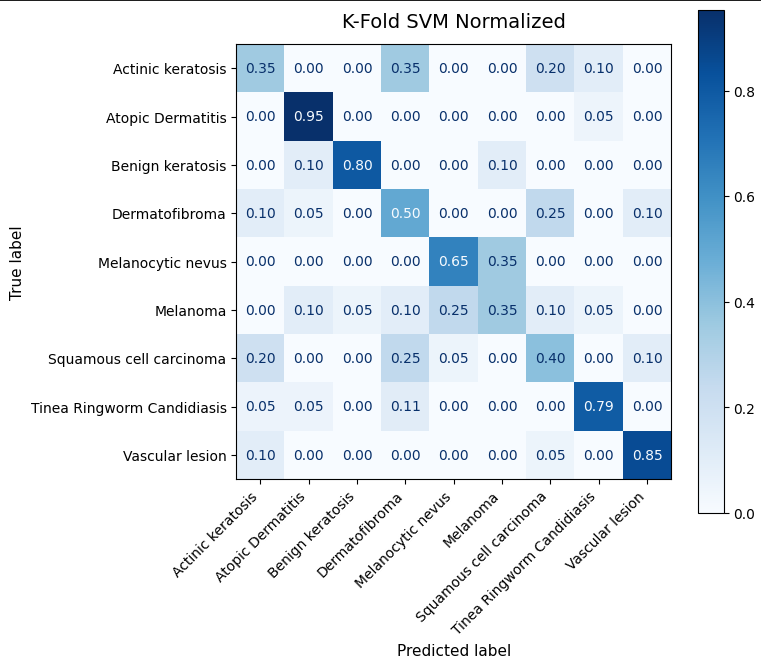 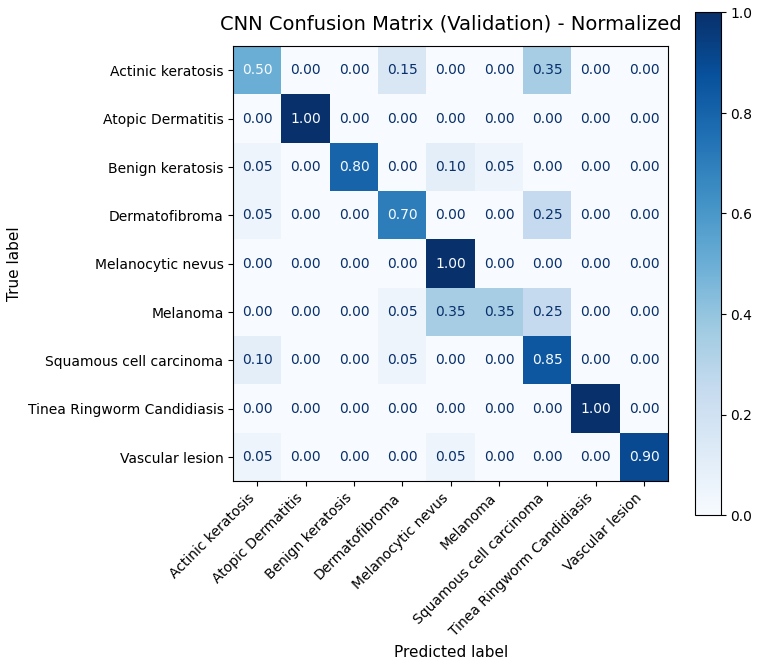

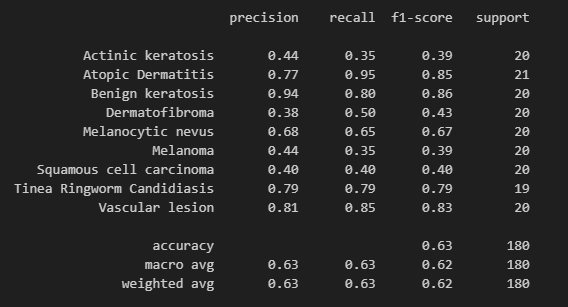 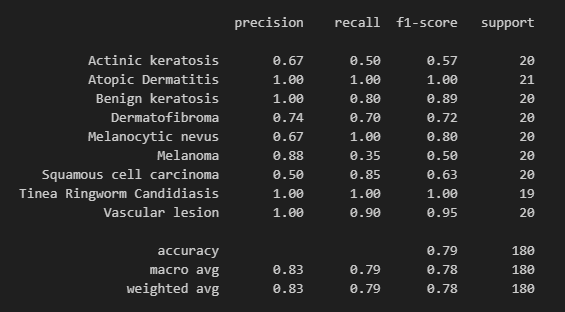

For the SVM, there were a few pitfalls. For starters, actinic keratosis was often misclassified as Dermatofibroma, and more seldom classified as either Squamous or Tinea. With a recall of 0.35, that shows that the model really struggled with identifying it. CNN did improve on this a little bit, but still, the recall was only 0.5, which is not a good rate at all. That means that 50% of the cases were misclassified, which means that something about this specific disease is difficult to track in this regard. SVM also struggled with Melanoma, and looking at the recall rate we can see that CNN did not improve on that front. However, the precision doubled when moving to CNN, which suggests that it was a bit more conservative in labeling a disease as melanoma. Taking a closer look at the SVM confusion matrix, we can see that Nevus gets classified as Melanoma 35% of the time, which suggests that the boundary between the 2 is unstable in this feature space. Squamous also struggles to be classified, with a low precision and recall and the second lowest F1 score for SVM. It gets mixed with multiple classes rather than one clear confusion, which is a sign that the feature spcae is not class-separable for Squamous. However, that isn't to say that SVM didn't classify anything correctly. Atopic Dermatitis, Benign Keratosis, Tinea, and Vascula Lesion all had very high recall rates, which shows they were identified overall. 

From a quick glance, it is very clear that on the diagonals CNN performed either the same or better across every single class. The validation accuracy was 0.79, and the macro average for precision was 0.83, recall 0.79, and the F1 score as 0.78. Again, because the weighted and macro averages are similar, it means that the overall performance isn't being dominated by one huge class. We can notice clearly, from the numbers and the colors, that Melanoma is still a weakness like mentioned before. A low recall rate is likely more dangerous than a low precision. The model is very conservative about calling out Melanoma, but when it comes down to it, Melanoma needs to be caught early. This could potentially be fixed by using class-weight cross entrop to penalize missing melanoma more. It would also make sense to potentially fine-tune later ResNet blocks by unfreezing the last stage, but with a lower learning rate to adapt features to the medical domain. Squamous has the opposite issue, with a low precision and high recall, essentially meaning it is being classified a lot. Many images from other classes get incorrectly labeled as Squamous. This essentially means it's acting like a fall-back class; if you're unsure, then just pick squamous. This suggests that there is feature overlap. A possibel next step is inspecting these images to see if the predictions correlate with lighting, zoom, or background. Memlanocytic nevus has a perfect recall, meaning every case was found, but it also predicts nevus for non-nevus cases, particularly for melanoma. This is more clearly linked with one other class, that being melanoma, so inspecting the similarities there and following the steps mentioend for melanoma would probably be the next best step. There were many strong classes, like Atopic Dermatitis and Tinea Ringworm Candidiasis both with perfect scores across the board. Vascular Lesion also had a perfect precision and near perfect recall. This suggests that these classes have visual patterns which are distinct in this dataset. Future work would confirm just how distinct these features are. 

Again, overall CNN clearly improves the accuracy, but interestingly they do still have some similar pitfalls. Melanoma remains low recall, and Squamous is still confused with other classes. Looking through the differences in the datasets was quite fun, and I will definitely be analyzing it more after the semester ends.

## Ethical Concerns



As with any medical dataset, patience privacy and identifiability is always a concern. The images labeled as Atopic Dermatitis specifically were more zoomed out, and often contained facial features such as the mouth, cheek, or nose. Furthermore, some images contained hands with rings, which could be identifiaible as well. Ethical use requires de-identification of data, and careful storag/access control. 

Another huge ethical concern is with the demographics, or rather demographic, represented in the data. Only white-skinned individuals were represented in the data. One could argue that this makes it easier to learn for the model, since the contrast is most likely higher, however, that means that if this model were to be used on any person of color it would perform poorly. This is definitely a concern and would need to be addressed by simply expanding the dataset, or specifying that this is not applicable across skin colors. 

There is also a harm from misclassification, especially false negatives. A false negative for a condition like melanoma would be particularly problematic as delaying treatment for a disease like that is very serious. Incorrectly classifying someone as having melanoma is also quite dnagerous, as it could lead to treatment which they do not need, and delay treatment for the actual disease. This is why both recall and precision are important together, and having one high without the other is still an issue.

Overall, there are many different issues to consider when it comes to the ethical concerns regarding datasets. I listed a few, but in reality, misuse of data, data leakage, clinical ambiguity and many other things are all concerns which are valid to have.

## References

Nelson, Joseph. "You Might Be Resizing Your Images Incorrectly." November, 2025. https://blog.roboflow.com/you-might-be-resizing-your-images-incorrectly/

Buhl, Nikolaj. "F1 Score in Machine Learning." July, 2023. https://www.geeksforgeeks.org/deep-learning/categorical-cross-entropy-in-multi-class-classification/

Sabita. "Top Pre-Trained Models for Image Classification." July, 2025. https://www.geeksforgeeks.org/computer-vision/top-pre-trained-models-for-image-classification/

Karmakar, Tapendu. "Introduction to Resnet-18." November, 2024. https://www.kaggle.com/code/iamtapendu/introduction-to-resnet-18/notebook

Rupert ai. "ResNet (actually) explained in under 10 minutes." 2022. https://www.youtube.com/watch?v=o_3mboe1jYI

Futurology -- An Optimistic Future. "Convolutional Neural Networks Explained (CNN Visualized)." December 2020. https://www.youtube.com/watch?v=pj9-rr1wDhM